In [56]:
## Import Modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Plate Dimensions
x=1
y=1
## simulation paramaters
del_x=0.01
del_y=0.01
nx=int(1/del_x)+1
ny=int(1/del_y)+1
simulation_time=20

## material properties
alpha=1.65e-4 # Thermal Diffusivity 

## stability criteria
c=0.2
del_t= round((c* del_x**2)/alpha,2)

## MeshGrid
a=np.linspace(0,x,nx)
b=np.linspace(0,y,ny)
X,Y=np.meshgrid(a,b)
T=np.zeros((nx,ny))
T_final=[]
print(del_t)
print(nx,ny)

0.12
101 101


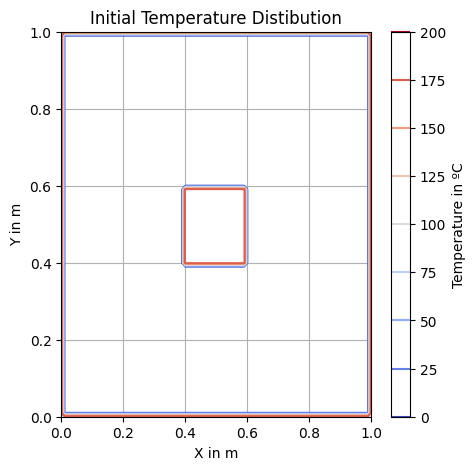

In [57]:
## Initial Condition
T[:,0]=200  #@ x=0
T[:,-1]=200 #@ x=1
T[0,:]=200  #@ y=0
T[-1,:]=200 #@ y=1

T[40:60,40:60]=200

T_current=T
T_previous=T_current
T_next=np.zeros((nx,ny))
##plot Initial condition
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot()
ax.set_title("Initial Temperature Distibution")
ax.set_xlabel("X in m")
ax.set_ylabel("Y in m")
ax.grid(True)

contour=ax.contour(X,Y,T,cmap="coolwarm")
cbar=fig.colorbar(contour,ax=ax)
cbar.set_label("Temperature in ºC")
plt.show()

In [58]:
## solve the equation transient state
for t in range(0,int(simulation_time/del_t)):
    for i in range(1,nx-1):
        for j in range(1,ny-1):
            t_next= T_previous[i][j]+ ((alpha*del_t)/(del_x**2))*(T_current[i+1,j] - 2*T_current[i,j] +T_current[i-1,j]) + ((alpha*del_t)/(del_y**2))*(T_current[i,j+1] - 2*T_current[i,j] +T_current[i,j-1]) 
            T_next[i][j]=t_next
    
    T_current=T_next.copy()
    T_previous=T_current.copy()
    T_final.append(T_current)

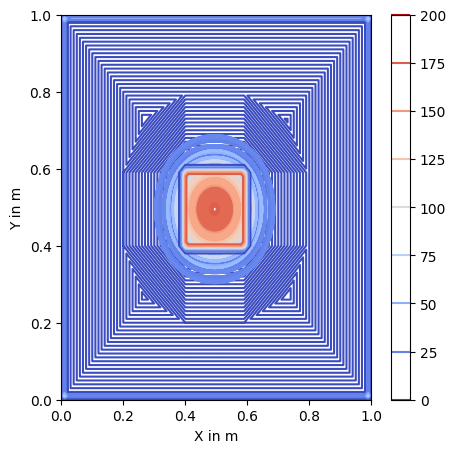

In [59]:
## animate the 
fig1=plt.figure(figsize=(5,5))
ax1=fig1.add_subplot()
ax1.set_xlabel("X in m")
ax1.set_ylabel("Y in m")
contour1=ax1.contour(X,Y,T_final[0],cmap="coolwarm")
cbar1=fig1.colorbar(contour1,ax=ax1)
cbar.set_label("temperature in  ºC")
def animate(i):
    ax1.contour(X,Y,T_final[i],cmap="coolwarm")

anim=animation.FuncAnimation(fig1,animate,frames=int(simulation_time/del_t))
writer=animation.FFMpegWriter(fps=(30))
anim.save("Temperature_distribution.mp4",writer=writer)